In [60]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import emoji
from nltk.corpus import stopwords
from pymorphy2 import MorphAnalyzer
import nltk
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
data = pd.read_csv('../data/geo-reviews-dataset-2023.csv')

In [3]:
data.head()

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...


In [28]:
for rubric in data['rubrics'].unique():
    print(rubric)

Жилой комплекс
Магазин продуктов;Продукты глубокой заморозки;Магазин мяса, колбас
Фитнес-клуб
Пункт проката;Прокат велосипедов;Сапсёрфинг
Салон красоты;Визажисты, стилисты;Салон бровей и ресниц
Оператор сотовой связи;Интернет-провайдер
Кафе
Вейп-шоп;Магазин табака и курительных принадлежностей
Кафе;Кофейня
Магазин обуви;Ювелирный магазин;Детские игрушки и игры
Пляж
Кондитерская
Ресторан
Магазин подарков и сувениров;Музыкальный магазин
Гостиница
Кафе;Быстрое питание;Доставка еды и обедов
Автомойка
Пекарня
Салон бровей и ресниц
Кафе;Ресторан;Столовая
Компьютерный магазин;Компьютерный ремонт и услуги
Хостел
Быстрое питание
Магазин мебели
Косметология;Салон красоты;Ногтевая студия;Эпиляция
Фитнес-клуб;Спа-салон;Салон красоты
Магазин цветов;Магазин подарков и сувениров;Товары для праздника
Мягкая мебель;Корпусная мебель
Эпиляция
Аптека
Автомобильные грузоперевозки;Перевозка негабаритных грузов
Супермаркет;Магазин продуктов
Косметология;Салон красоты
Фотоуслуги;Художественный салон;Магазин п

В рамках данного проекта будет рассматриваеться только завдения общепита

In [30]:
need_rubricks = set(["Кафе", "Ресторан", "Столовая", "Кофейня", "Бар", "Пиццерия", "Паб"])
df = data[data['rubrics'].apply(lambda x: bool(set(map(str.strip, x.split(';'))) & need_rubricks))]

In [39]:
df.to_csv('../data/rewiew_restorants.csv', index=False)

# EDA

In [41]:
df = pd.read_csv('../data/rewiew_restorants.csv')

In [42]:
df.describe()

,rating,num_chars,num_words,num_emojis
count,103133.000000,103133.000000,103133.000000,103133.000000
mean,4.443243,279.791425,40.627733,0.315554
std,1.152648,250.258497,38.553536,1.245566
min,0.000000,6.000000,1.000000,0.000000
25%,5.000000,139.000000,19.000000,0.000000
50%,5.000000,204.000000,29.000000,0.000000
75%,5.000000,336.000000,49.000000,0.000000
max,5.000000,6613.000000,1055.000000,65.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103133 entries, 0 to 103132
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   address     103133 non-null  object 
 1   name_ru     102936 non-null  object 
 2   rating      103133 non-null  float64
 3   rubrics     103133 non-null  object 
 4   text        103133 non-null  object 
 5   num_chars   103133 non-null  int64  
 6   num_words   103133 non-null  int64  
 7   num_emojis  103133 non-null  int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 6.3+ MB


В датасете нет пропусков и все признаки имеют нужный тип данных.

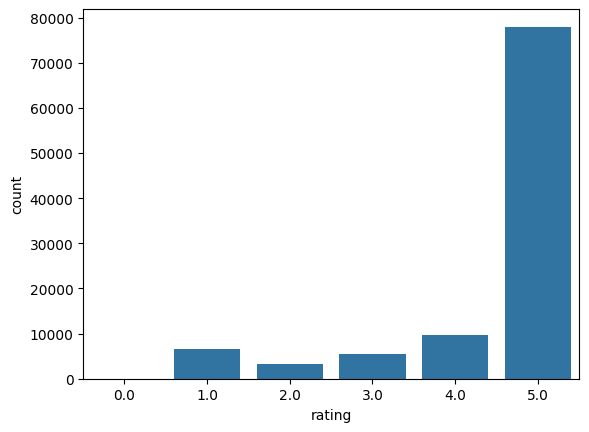

rating
5.0    78003
4.0     9582
1.0     6630
3.0     5518
2.0     3359
0.0       41
Name: count, dtype: int64

In [44]:
sns.countplot(x='rating', data=df)
plt.show()
df.rating.value_counts()

Присуствует сильный дисбаланс классов. В дальнейшем это надо учесть. 

In [45]:
df['num_chars'] = df['text'].str.len()
df['num_words'] = df['text'].str.split().apply(len)

print(df[['num_chars', 'num_words']].describe())


           num_chars      num_words
count  103133.000000  103133.000000
mean      279.791425      40.627733
std       250.258497      38.553536
min         6.000000       1.000000
25%       139.000000      19.000000
50%       204.000000      29.000000
75%       336.000000      49.000000
max      6613.000000    1055.000000


В целом отзывы имеют длину примерно в 40-50 слов

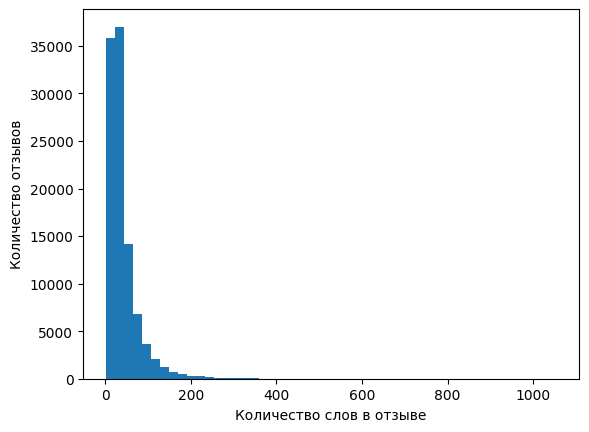

In [49]:
plt.hist(df['num_words'], bins=50)
plt.xlabel("Количество слов в отзыве")
plt.ylabel("Количество отзывов")
plt.show()


In [50]:
df.groupby(['rating'])['num_chars'].mean()

rating
0.0    250.121951
1.0    509.644042
2.0    519.458172
3.0    430.187930
4.0    323.572741
5.0    233.932323
Name: num_chars, dtype: float64

In [51]:
df.groupby(['rating'])['num_words'].mean()

rating
0.0    36.097561
1.0    78.735294
2.0    80.030366
3.0    65.513592
4.0    47.956898
5.0    33.033550
Name: num_words, dtype: float64

In [53]:
q95 = df['num_words'].quantile(0.95)
print(q95)
print(f'Количество отзывов длинее {q95}', df[df['num_words'] > q95].shape[0])
print(f'Количество отзывов короче {q95}', df[df['num_words'] < q95].shape[0])
maxWords = 200
print(maxWords)
print(f'Количество отзывов длинее {maxWords}', df[df['num_words'] > maxWords].shape[0])
print(f'Количество отзывов короче {maxWords}', df[df['num_words'] < maxWords].shape[0])
q5 = df['num_words'].quantile(0.05)
print(q5)
print(f'Количество отзывов длинее {q5}', df[df['num_words'] > q5].shape[0])
print(f'Количество отзывов короче {q5}', df[df['num_words'] < q5].shape[0])

110.0
Количество отзывов длинее 110.0 5139
Количество отзывов короче 110.0 97883
200
Количество отзывов длинее 200 973
Количество отзывов короче 200 102144
9.0
Количество отзывов длинее 9.0 96877
Количество отзывов короче 9.0 4713


Можно заметить, что негативные отзывы заметно длинее положительных

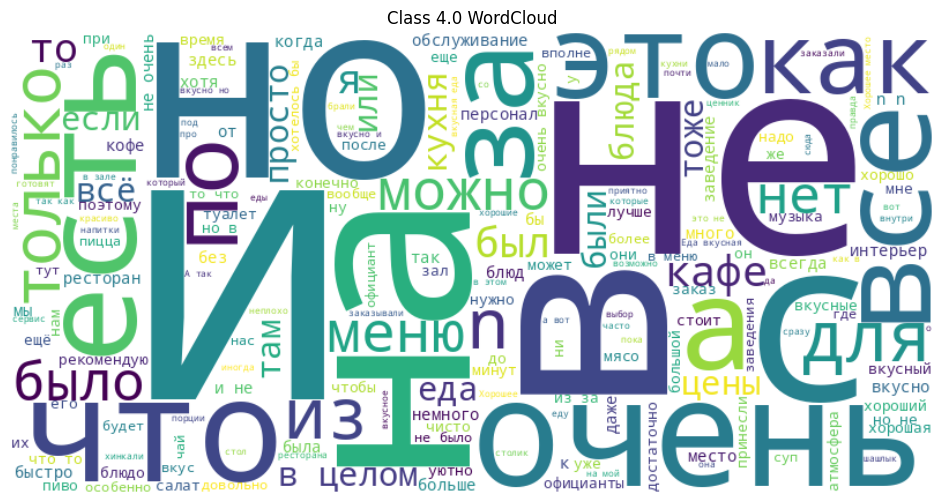

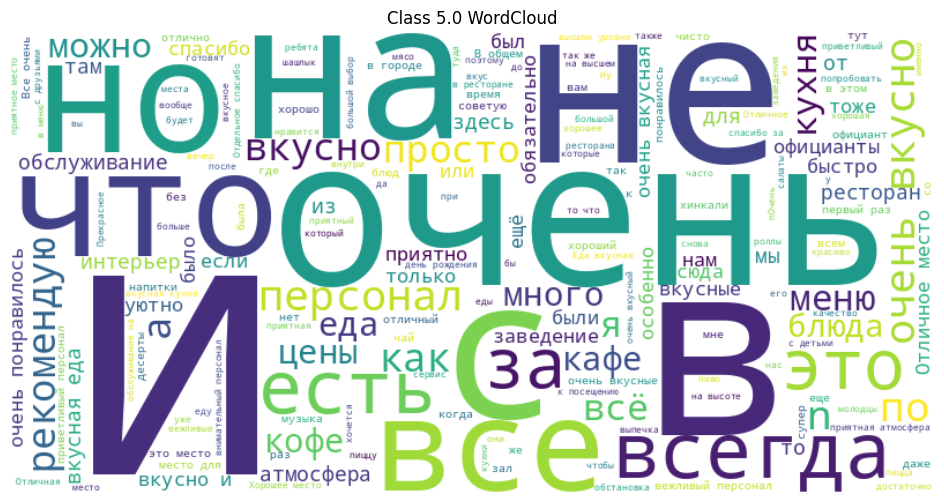

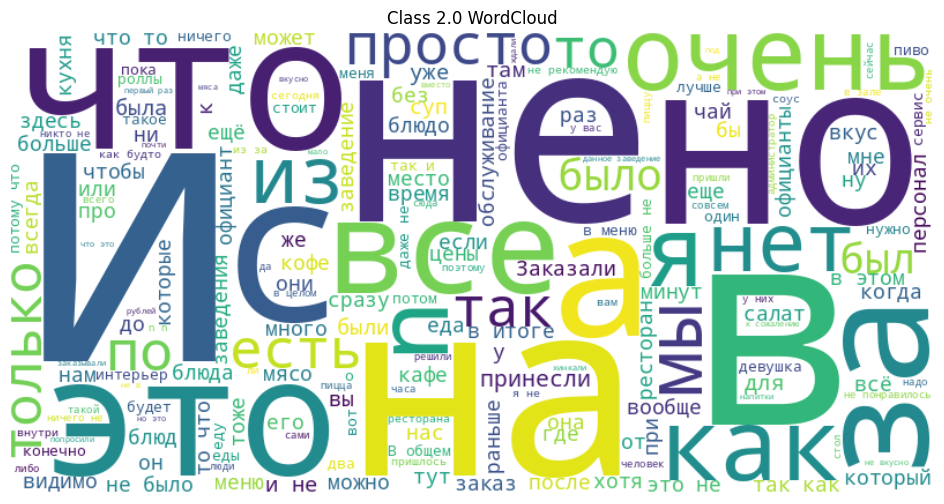

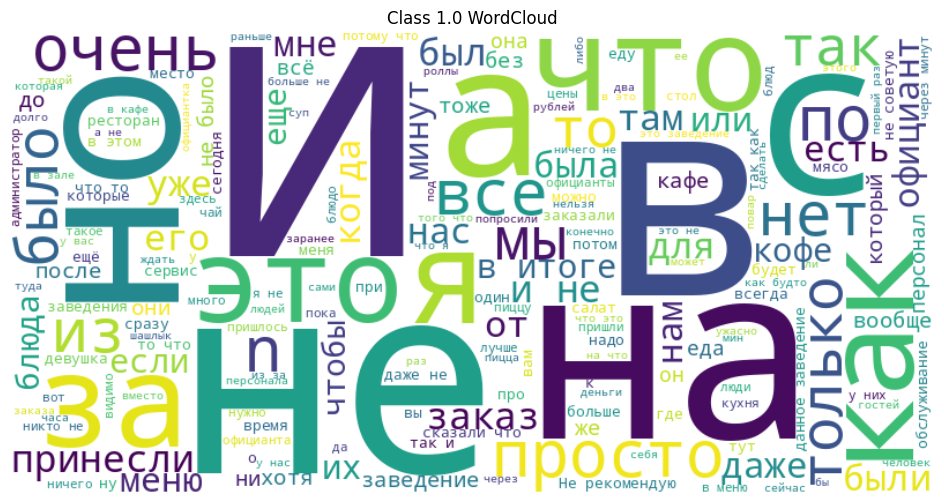

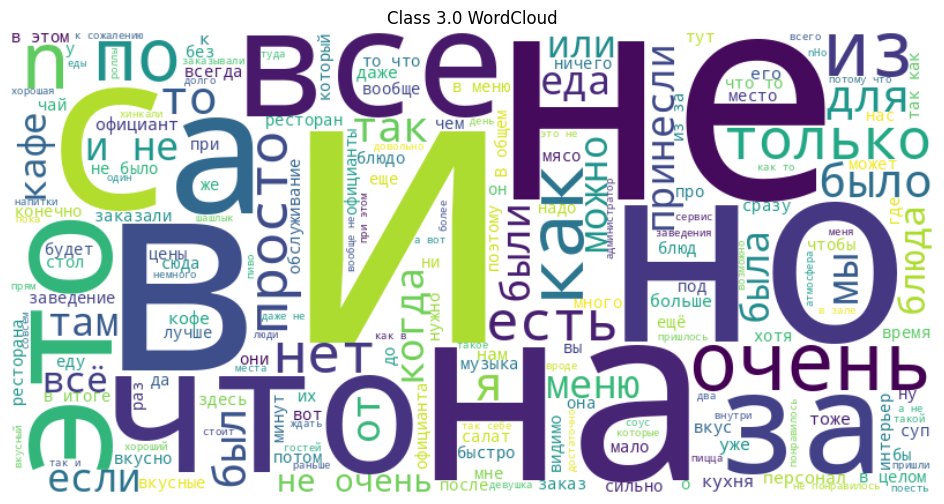

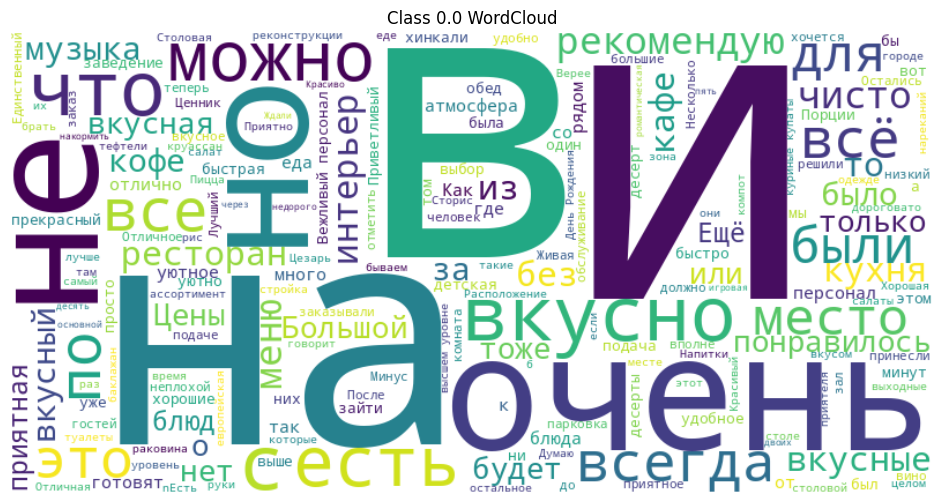

In [54]:
classes = df['rating'].unique()


sample_size = 2000 

for cls in classes:
    # выбираем случайную подвыборку по классу
    df_sample = df[df['rating'] == cls].sample(
        n=min(sample_size, len(df[df['rating'] == cls])),
        random_state=42
    )
    
   
    text = " ".join(df_sample['text'])
    

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Class {cls} WordCloud')
    plt.show()


Попробуем посмотреть на биграммы

Можно заметить: 
- много стоп слов
- В положительных отзывах слово "НЕ" имеет меньший вес
- В негативных отзывах люди часто упоминают слова "деньги", "цена", в то время как у положительных отзывов много положительных слов и про финансы не упоминают
- Часто встречается слово персонал или сервис 

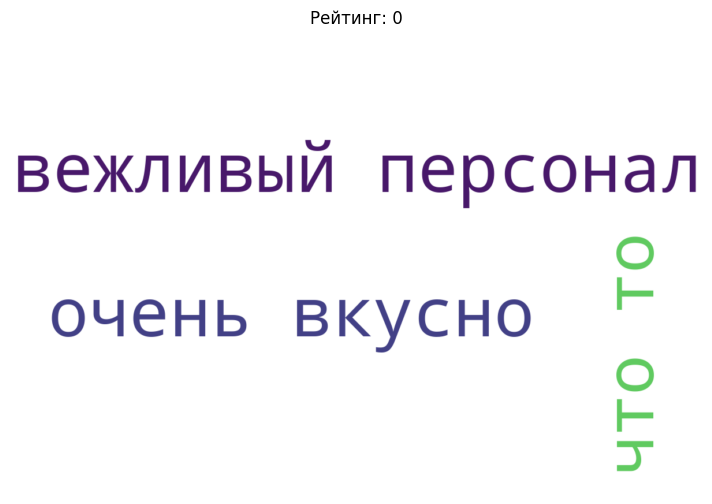

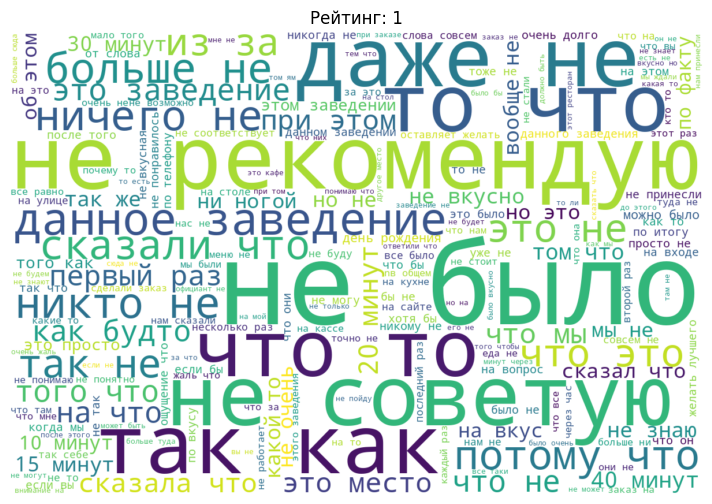

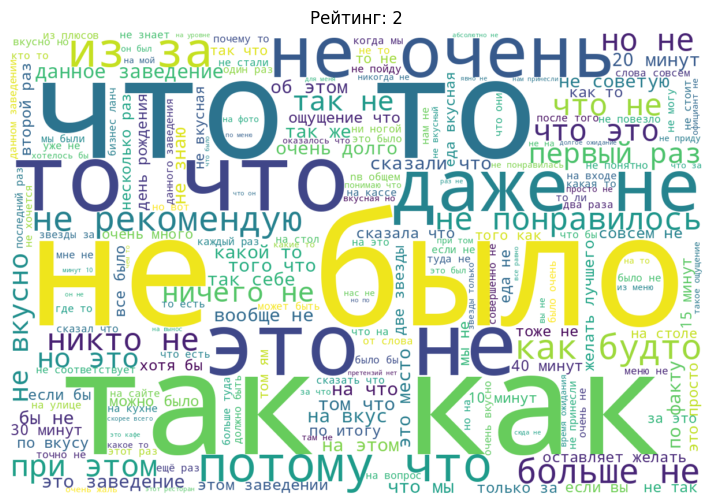

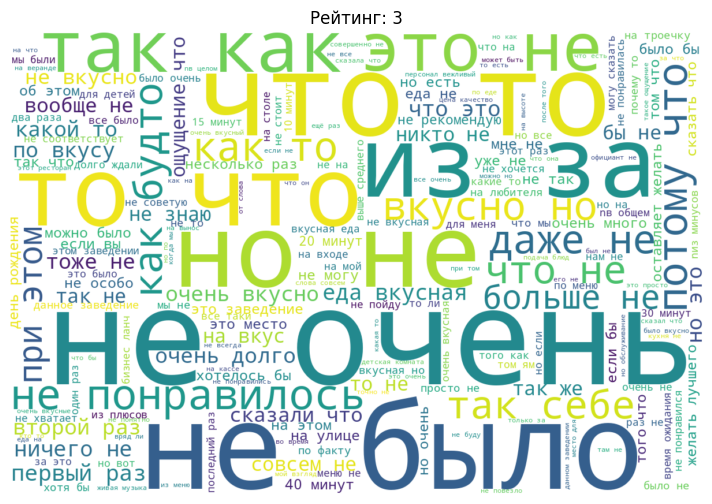

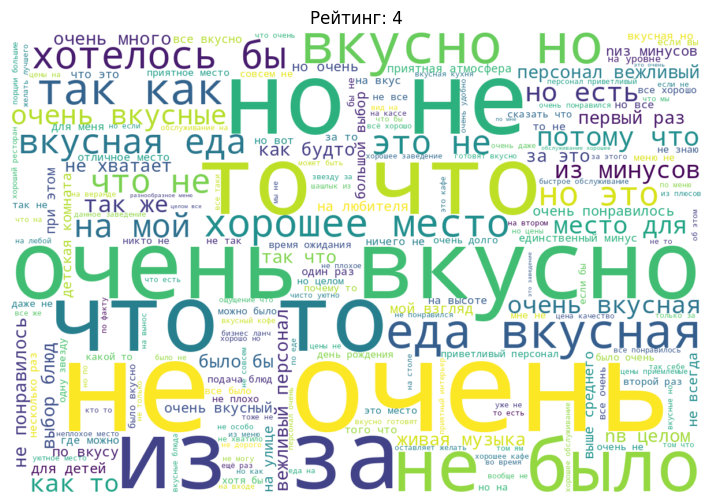

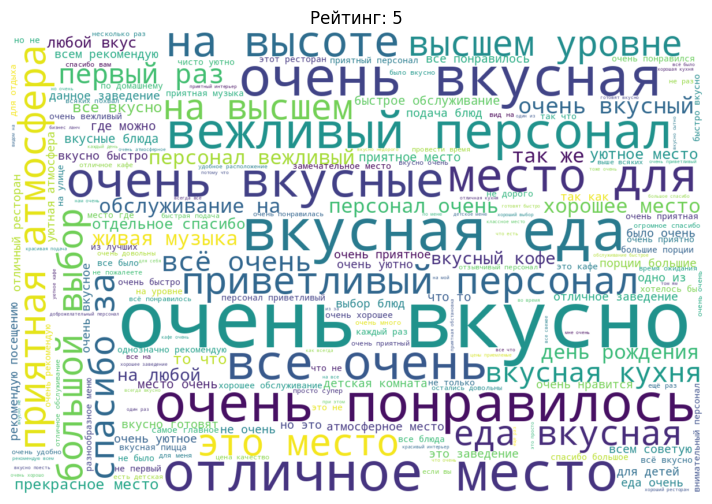

In [62]:
def quick_clean(t):
    t = str(t).lower()
    t = ''.join(c for c in t if c not in emoji.EMOJI_DATA)
    t = re.sub(r'[^a-zа-яё0-9\s]', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['text_clean'] = df['text'].apply(quick_clean)

def wordcloud_by_rating(df, rating):
    texts = df.loc[df['rating'] == rating, 'text_clean']
    if texts.empty:
        return
    
    vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=3)
    X = vectorizer.fit_transform(texts)
    freqs = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))
    
    wc = WordCloud(width=1200, height=800, background_color="white")
    wc.generate_from_frequencies(freqs)
    
    plt.figure(figsize=(10,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Рейтинг: {rating}")
    plt.show()

for r in range(0, 6):
    wordcloud_by_rating(df, r)


Биграммы подтверждают, что ключевое значение имеют меню, сервис, время ожидания и цена.
Так же облако точек для рейтинга 0 выглядит странно, возможно это выбросы. В дальнейшем их уберём из датасета. 

In [55]:
def count_emojis(text):
    if not isinstance(text, str):
        text = str(text)
    
    return sum(1 for c in text if c in emoji.EMOJI_DATA)

df['num_emojis'] = df['text'].apply(count_emojis)

In [56]:
df['num_emojis'].describe()

count    103133.000000
mean          0.315554
std           1.245566
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          65.000000
Name: num_emojis, dtype: float64

In [58]:
textEmoji = df[df['num_emojis'] > 0]

In [59]:
print(textEmoji.iloc[0]['text'])

5 из 5🖤 Пил кофе и в Риме, и в  Париже, но вкуснее, чем капуч на фундучном молоке с фирменными сливками Джинжу, не пробовал ничего! Десерты тоже очень необычные. Ребята - бариста большие молодцы! \n\nЧто можно улучшить? Маловато места, с посадкой можно что-то придумать?



В тексте есть emoji, надо подумать как их обрабатывать

# Prerprocessing classicalML

In [19]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/rustam/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

В рамках нашей задачи для нас важны только rating и text

In [64]:
dfClassical = df[['text', 'rating']].copy()
dfClassical = dfClassical[dfClassical['rating']!=0.0]

В данной задаче для дальнейшей аналитики важнее уметь находить отрицательные отзывы. Так же облака точек показали, что отзывы с оценкой 3 ближе к отрицательным, поэтому превратим задачу в бинарную классификацию: 
- 1 - 3 - отрицательные
- 4 - 5 - положительные

Отрицательные отзывы будут обозначены 1.

In [65]:
dfClassical['setniment'] = dfClassical['rating'].apply(lambda x: 1 if x <= 3 else 0)

In [66]:
def preprocess_text(text):
    stop_words = set(stopwords.words('russian'))
    morph = MorphAnalyzer()

    MAX_WORDS = 200
    if not isinstance(text, str):
        text = str(text)
    
   
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    
  
    text_lem = " ".join([morph.parse(word)[0].normal_form for word in text.split()])
    
    text_clean = " ".join([w for w in text_lem.split() if w not in stop_words])
    
    words = text_clean.split()
    if len(words) > MAX_WORDS:
        text_clean = " ".join(words[:MAX_WORDS])
    
    return text_clean
    

In [67]:
dfClassical['text_clean'] = dfClassical['text'].apply(preprocess_text)

/home/rustam/miniconda3/envs/nlp/lib/python3.10/site-packages/pymorphy2/analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [68]:
dfClassical

,text,rating,setniment,text_clean
0,Глубинка страны во всех своих проявлениях. Асс...,4.0,0,глубинка страна весь свой проявлениях. ассорти...
1,"5 из 5🖤 Пил кофе и в Риме, и в Париже, но вку...",5.0,0,"5 5🖤 пить кофе риме, париже, вкуснее, капучий ..."
2,"Не очень удобное расположение, от метро идти м...",4.0,0,"очень удобный расположение, метро идти мина 20..."
3,"Самый большой плюс это месторасположение, набе...",2.0,1,"самый большой плюс это месторасположение, набе..."
4,Добрый день! Сегодня во второй раз посетили с ...,5.0,0,добрый день! сегодня второй посетить дочка рес...
...,...,...,...,...
103128,"Вкуснейшая еда, отличный персонал, ребята моло...",5.0,0,"вкусный еда, отличный персонал, ребята молодцы..."
103129,"Залетели ночью с друзьями, разбудили работника...",1.0,1,"залететь ночью друзьями, разбудить работника, ..."
103130,Очень вкусная пицца. Нравится их система лояль...,5.0,0,очень вкусный пицца. нравиться система лояльно...
103131,"Пицца детям понравилась, интерьер очень интере...",5.0,0,"пицца ребёнок понравилась, интерьер очень инте..."


In [69]:
dfClassical.to_csv('../data/rewiew_restorants_classical.csv', index=False)